# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    print('Downloading the course resources...')
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
else:
    print('Using the existing course folder; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 09</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Atención causal</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/09_atencion_causal_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo impedimos que una posición use información futura durante la predicción autoregresiva?

En el notebook anterior vimos que la autoatención no restringida permite que cada posición consulte todas las posiciones de la secuencia. Eso es útil para muchos problemas, pero viola la regla central de un modelo autoregresivo: al predecir el siguiente token, una posición no debe mirar tokens futuros.

La atención causal introduce una restricción explícita sobre la matriz de atención. No cambia los datos de entrada; cambia las rutas de información permitidas antes de aplicar softmax.


## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar por qué la autoatención no restringida produce fuga de información en predicción autoregresiva.
2. Construir e interpretar una máscara triangular causal con condición $j \le t$.
3. Aplicar la máscara antes de softmax y verificar que las posiciones futuras reciben peso cero.
4. Comparar atención causal contra atención sin máscara usando tablas y matrices de calor.
5. Reconocer el límite de la máscara: impide mirar el futuro, pero no garantiza comprensión ni calidad de generación.


## Marco conceptual

Durante el entrenamiento, el entorno de cómputo contiene la secuencia completa en memoria. Sin embargo, el objetivo autoregresivo exige simular una condición temporal: para predecir en la posición $t$, el modelo solo puede usar información de posiciones anteriores y de la posición actual.

En este notebook, **causal** no significa causalidad científica, estadística o filosófica. Significa una restricción de orden: una posición no puede consultar tokens que todavía no existirían durante la generación autoregresiva.

La máscara causal implementa esa restricción sobre la matriz de puntajes de atención. Antes de softmax, las posiciones futuras reciben un valor imposible. Después de softmax, esas posiciones quedan con peso cero.

La diagonal queda permitida porque la salida de la posición $t$ se construye desde la representación disponible en esa misma posición. Bloquear la diagonal dejaría a cada posición usando solo pasado estricto, lo cual no corresponde a la forma habitual del bloque Transformer decoder.


## Idea visual: futuro bloqueado antes de softmax

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/09_atencion_causal.png" alt="Atención causal" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 8px;">
</div>

La imagen resume el punto central: una fila de atención puede consultar pasado y presente, pero no futuro. La máscara actúa antes de softmax; por eso los pesos sobre posiciones futuras terminan en cero.


## Formulación matemática

Sea $S \in \mathbb{R}^{T \times T}$ la matriz de puntajes antes de softmax, donde $S_{tj}$ compara la consulta de la posición $t$ con la llave de la posición $j$.

La máscara causal define qué posiciones están permitidas:

$$
M_{tj} =
\begin{cases}
1, & j \le t, \\
0, & j > t.
\end{cases}
$$

Esta ecuación se lee así: para la fila $t$, solo las columnas $j$ ubicadas en el pasado o en la posición actual quedan habilitadas; las columnas futuras quedan prohibidas.

La diagonal $j=t$ queda permitida. Esa celda representa la posición actual, no el futuro. En un decoder autoregresivo, la representación de la posición actual se usa para producir la salida asociada a esa posición.

La máscara se aplica a los puntajes antes de softmax:

$$
\tilde{S}_{tj} =
\begin{cases}
S_{tj}, & M_{tj}=1, \\
-\infty, & M_{tj}=0.
\end{cases}
$$

Esta ecuación se lee así: los puntajes permitidos se conservan y los puntajes futuros se reemplazan por un valor que softmax transformará en peso cero.

Después se calcula:

$$
A_{tj}=\operatorname{softmax}(\tilde{S}_{t,:})_j.
$$

Esta ecuación se lee así: cada fila se normaliza solo sobre las posiciones permitidas. Por eso, para $j>t$, se obtiene $A_{tj}=0$.

La máscara no se aplica sobre $V$ ni sobre la salida $Y$. Primero bloquea puntajes futuros en $S$; luego softmax produce pesos válidos; finalmente esos pesos mezclan valores.


## Traducción tensorial

Para una secuencia, la máscara causal tiene forma:

$$
M \in \{0,1\}^{T \times T}.
$$

En un lote o en varias cabezas, los puntajes suelen tener forma:

$$
S \in \mathbb{R}^{B \times H \times T \times T}.
$$

La misma máscara causal puede compartirse sobre los ejes de batch y heads:

$$
M \in \{0,1\}^{T \times T}
\quad \rightarrow \quad
M_{broadcast} \in \{0,1\}^{1 \times 1 \times T \times T}.
$$

Esta ecuación se lee así: la regla temporal es la misma para todos los ejemplos del batch y para todas las cabezas; lo que cambia son los puntajes, no la estructura de posiciones permitidas.

Computacionalmente, no es necesario copiar la máscara muchas veces. Basta con darle una forma que pueda transmitirse sobre $B$ y $H$. Lo importante es garantizar que cada fila $t$ bloquee las columnas futuras $j>t$.

Esta máscara es distinta de una **padding mask**. La máscara causal bloquea futuro por orden autoregresivo; la padding mask bloquea posiciones vacías agregadas para igualar longitudes.


## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.atencion_experimentos as atencion_experimentos
import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.visualizacion as visualizacion

atencion_experimentos = importlib.reload(atencion_experimentos)
componentes_interactivos = importlib.reload(componentes_interactivos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_atencion_causal = componentes_interactivos.crear_explorador_atencion_causal
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento mínimo

Construiremos una secuencia de $T=6$ posiciones y compararemos atención causal contra atención sin máscara. La pregunta experimental es directa: ¿cuánta masa de atención cae sobre posiciones futuras?


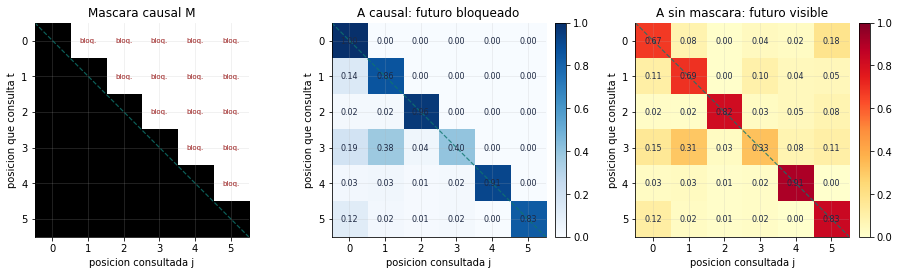

In [2]:
resultado_causal = atencion_experimentos.preparar_atencion_causal(seed=4)

mostrar_tablas_en_columnas(
    [
        ("Auditoría de objetos", resultado_causal.resumen),
        ("Masa futura por fila", resultado_causal.comparacion),
        ("Lectura de la fila t=3", resultado_causal.fila),
        ("Verificaciones", resultado_causal.verificaciones),
    ],
    min_width="360px",
)


La tabla de la fila $t=3$ muestra la transición completa: primero existen puntajes para todas las columnas; después la máscara reemplaza el futuro por $-\infty$; finalmente softmax asigna peso cero a esas columnas y renormaliza la masa sobre pasado y presente.

La comparación con atención sin máscara separa el problema con claridad: sin máscara, una fila puede asignar masa positiva a posiciones futuras. Eso sería fuga de información para entrenamiento autoregresivo.


## Visualización comparativa

La primera matriz muestra la máscara: las celdas permitidas están en la parte triangular inferior, incluida la diagonal. La segunda muestra los pesos causales después de softmax. La tercera muestra los pesos sin máscara, donde pueden aparecer pesos sobre posiciones futuras.


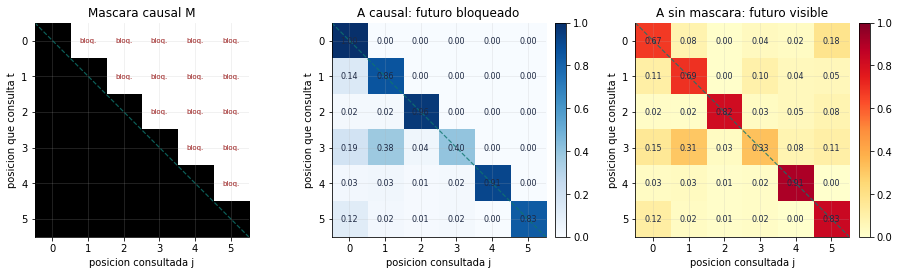

In [3]:
display(resultado_causal.figura)
plt.close(resultado_causal.figura)


La diferencia importante no es estética: la matriz causal elimina toda ruta por encima de la diagonal. La matriz sin máscara conserva esas rutas, por lo que una posición podría usar información que no estaría disponible durante generación autoregresiva.


## Explorador interactivo

El explorador permite seleccionar una fila $t$ y comparar dos modos: causal y sin máscara. Observa especialmente la masa futura. En modo causal debe ser cero; sin máscara puede ser positiva.

La lectura importante es local: cada fila representa una posición que consulta. Para esa fila, las columnas $j>t$ son futuro y quedan bloqueadas, mientras la diagonal $j=t$ queda permitida.


In [4]:
crear_explorador_atencion_causal()


## Verificación de aprendizaje

Usa el explorador y responde con evidencia:

1. Selecciona una fila intermedia, por ejemplo $t=2$ o $t=3$. ¿Qué columnas quedan bloqueadas?
2. Compara la masa futura en modo causal y en modo sin máscara. ¿Qué evidencia numérica observas?
3. Explica por qué la diagonal queda permitida.
4. ¿Qué pasaría si también se bloqueara la diagonal?
5. Diferencia una máscara causal de una padding mask.
6. ¿Por qué una máscara causal correcta no garantiza por sí sola que el modelo genere buen texto?


## Análisis crítico

Lo observado puede leerse en cuatro niveles:

1. **Qué ocurrió:** la máscara reemplazó puntajes futuros por $-\infty$ antes de softmax y los pesos futuros quedaron en cero.
2. **Por qué ocurrió:** softmax asigna probabilidad nula a posiciones con puntaje $-\infty$, y renormaliza la masa entre posiciones permitidas.
3. **Qué sí controla:** controla rutas de información dentro de la matriz de atención para respetar el orden autoregresivo.
4. **Qué no controla:** no mejora por sí sola los datos, las representaciones, la optimización ni la capacidad lingüística del modelo.

La causalidad aquí es una propiedad estructural del cómputo, no una afirmación causal en sentido estadístico o filosófico. Tampoco debe confundirse con padding: causal bloquea futuro; padding bloquea posiciones vacías.


## Síntesis

La cadena operacional del notebook es:

$$
S \rightarrow M \rightarrow \tilde{S}=\operatorname{enmascarar}(S,M) \rightarrow A=\operatorname{softmax}(\tilde{S}) \rightarrow Y=AV.
$$

Esta cadena se lee así: los puntajes se filtran con una máscara causal antes de softmax, y luego los pesos permitidos mezclan valores.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que la atención causal conserva el cálculo matricial de atención, pero elimina rutas de información hacia el futuro para respetar el objetivo autoregresivo. La misma regla triangular puede compartirse sobre batch y cabezas.
</div>


## Preguntas de discusión

1. ¿Por qué en entrenamiento existe el futuro en memoria, pero debe ocultarse al cálculo de atención?
2. ¿Por qué la máscara se aplica antes de softmax y no después?
3. ¿Qué significa que la masa futura sea exactamente cero en la matriz causal?
4. ¿Qué error experimental se cometería si se entrenara un modelo autoregresivo sin máscara causal?
5. ¿Cómo prepara esta restricción el paso hacia atención multi-cabeza?


## Continuidad

El siguiente notebook divide la atención en varias cabezas. La máscara causal seguirá siendo necesaria, pero ahora deberá aplicarse dentro de cada cabeza para mantener la misma restricción autoregresiva en todos los subespacios de atención.
